# Notebook 2 — Text Preprocessing

We build three parallel representations of each song's lyrics:

| View | Purpose |
|------|---------|
| **raw** | Original text with case and punctuation preserved. Used by transformer-based sentiment models that depend on these signals. |
| **tokens** | Lowercased, punctuation-stripped word list. Used for n-gram frequency analysis, vocabulary statistics. |
| **lemmas** | Tokens reduced to dictionary base form, stopwords removed. Used for topic modeling and semantic analysis. |

We also compute per-song statistics (length, lexical diversity) and detect the dominant language, since the corpus contains Spanish and other non-English entries that some downstream analyses need to filter out.

**Output:** `data/processed/songs_preprocessed.parquet` — used by all subsequent notebooks.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Enable tqdm for pandas .progress_apply()
tqdm.pandas()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_lyrics.parquet")
print(f"Loaded {len(df):,} songs")
df.head(3)

Loaded 6,707 songs


,id,year,decade,rank,title,artist,title_norm,artist_norm,source,url,lyrics_text,word_count
0,1,2015,2010,1,Uptown Funk,Mark Ronson featuring Bruno Mars,uptown funk,mark ronson,genius,https://genius.com/Genius-traduzioni-italiane-...,"Doh\nDoh-doh-doh, doh-doh-doh, doh-doh\nDoh-do...",638.0
1,2,2015,2010,2,Thinking Out Loud,Ed Sheeran,thinking out loud,ed sheeran,genius,https://genius.com/Ed-sheeran-thinking-out-lou...,When your legs don't work like they used to be...,325.0
2,3,2015,2010,3,See You Again,Wiz Khalifa featuring Charlie Puth,see you again,wiz khalifa,genius,https://genius.com/Wiz-khalifa-see-you-again-l...,"It's been a long day\nWithout you, my friend\n...",438.0


## NLTK setup

First-time setup downloads tokenizers, lemmatizers, and stopword lists. Re-running is a no-op.

In [2]:
import nltk
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "averaged_perceptron_tagger"]:
    try:
        nltk.data.find(f"tokenizers/{resource}" if "punkt" in resource else f"corpora/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

ENGLISH_STOPWORDS = set(stopwords.words("english"))
# Keep some words that are stopwords technically but matter for music analysis
ENGLISH_STOPWORDS -= {"love", "loved", "loving", "want", "wants", "need", "needs", 
                      "feel", "feels", "down", "up", "over", "out"}
print(f"Stopwords: {len(ENGLISH_STOPWORDS)} (kept music-relevant words)")

Stopwords: 194 (kept music-relevant words)


## Language detection

We use `langdetect` for fast per-song language detection. It's not perfect on short or code-switching texts, but for our purposes (distinguishing English from Spanish/etc.) it's accurate enough.

If `langdetect` isn't installed, run `pip install langdetect` in your terminal, then restart the kernel.

In [3]:
from langdetect import detect, DetectorFactory, LangDetectException

# Make detection deterministic
DetectorFactory.seed = 42

def detect_lang(text: str) -> str:
    """Return ISO language code, or 'unknown' on failure."""
    try:
        # Use just the first 500 chars for speed — language is consistent
        return detect(text[:500])
    except LangDetectException:
        return "unknown"

df["language"] = df["lyrics_text"].progress_apply(detect_lang)
print("Language distribution:")
print(df["language"].value_counts().head(10))

  0%|          | 0/6707 [00:00<?, ?it/s]

Language distribution:
language
en    6538
es      70
tr      16
de      11
ru       9
so       9
tl       7
it       6
pt       6
id       6
Name: count, dtype: int64


## Tokenization & lemmatization

We build two cleaned token lists per song:

- **tokens**: lowercased, alphabetic-only, no stopwords removed. Good for raw frequency.
- **lemmas**: same as tokens but lemmatized (run→run, ran→run, running→run) and with stopwords removed. Good for semantic analysis.

We restrict to English songs for these representations, because lemmatization requires English-specific dictionaries. Non-English songs still keep their `raw` text for other analyses.

In [4]:
import re

LEMMATIZER = WordNetLemmatizer()

def tokenize(text: str) -> list[str]:
    """Lowercase, keep alphabetic + apostrophe-containing words."""
    text = text.lower()
    # Keep apostrophes inside words ("don't", "you'll")
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text)

def lemmatize_tokens(tokens: list[str]) -> list[str]:
    """Lemmatize and drop stopwords."""
    out = []
    for tok in tokens:
        if tok in ENGLISH_STOPWORDS:
            continue
        # Lemmatize as verb first (handles past tense like "loved"→"love")
        # then as noun (handles plurals "stars"→"star")
        lem = LEMMATIZER.lemmatize(LEMMATIZER.lemmatize(tok, pos="v"), pos="n")
        out.append(lem)
    return out

df["tokens"] = df["lyrics_text"].progress_apply(tokenize)
df["lemmas"] = df["tokens"].progress_apply(lemmatize_tokens)

# Sanity check
sample = df.iloc[0]
print(f"\nSample: '{sample['title']}' by {sample['artist']}")
print(f"Raw start:    {sample['lyrics_text'][:120]}")
print(f"Tokens start: {sample['tokens'][:15]}")
print(f"Lemmas start: {sample['lemmas'][:15]}")

  0%|          | 0/6707 [00:00<?, ?it/s]

  0%|          | 0/6707 [00:00<?, ?it/s]


Sample: 'Uptown Funk' by Mark Ronson featuring Bruno Mars
Raw start:    Doh
Doh-doh-doh, doh-doh-doh, doh-doh
Doh-doh-doh, doh-doh-doh, doh-doh
Doh-doh-doh, doh-doh-doh, doh-doh
Doh-doh-doh, d
Tokens start: ['doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh']
Lemmas start: ['doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh', 'doh']


## Per-song statistics

Compute features we'll use across many notebooks:

- **n_tokens**: total token count (length proxy)
- **n_types**: unique token count (vocabulary size)
- **ttr**: type-token ratio = `n_types / n_tokens` — high TTR means lexical variety; low TTR means repetition. Sensitive to length (longer texts mechanically have lower TTR), but we use it carefully.
- **mtld**: a length-corrected lexical diversity measure (more reliable than raw TTR for cross-length comparisons)
- **n_lines**: how many distinct lines
- **repetition_score**: fraction of lines that repeat — high for chorus-heavy pop

In [5]:
def compute_mtld(tokens: list[str], ttr_threshold: float = 0.72) -> float:
    """
    Measure of Textual Lexical Diversity (McCarthy & Jarvis, 2010).
    Returns a length-corrected lexical diversity score. Higher = more diverse.
    
    Walks through the tokens, restarting whenever cumulative TTR drops below
    the threshold (default 0.72). MTLD = total tokens / number of restarts.
    Works well for texts of varying length, unlike raw TTR.
    """
    if len(tokens) < 50:
        return float("nan")  # MTLD is unreliable on short texts
    
    def _mtld_pass(toks):
        factors = 0
        types = set()
        tok_count = 0
        for t in toks:
            tok_count += 1
            types.add(t)
            ttr = len(types) / tok_count
            if ttr <= ttr_threshold:
                factors += 1
                types = set()
                tok_count = 0
        # Partial factor for the trailing segment
        if tok_count > 0:
            ttr = len(types) / tok_count
            factors += (1 - ttr) / (1 - ttr_threshold)
        return len(toks) / factors if factors else float("nan")
    
    # Run forward and backward, average for stability
    fwd = _mtld_pass(tokens)
    bwd = _mtld_pass(list(reversed(tokens)))
    return (fwd + bwd) / 2


df["n_tokens"] = df["tokens"].str.len()
df["n_types"] = df["tokens"].progress_apply(lambda toks: len(set(toks)))
df["ttr"] = df["n_types"] / df["n_tokens"].replace(0, np.nan)
df["mtld"] = df["tokens"].progress_apply(compute_mtld)

def count_lines(text: str) -> int:
    return sum(1 for ln in text.split("\n") if ln.strip())

def repetition_score(text: str) -> float:
    lines = [ln.strip().lower() for ln in text.split("\n") if ln.strip()]
    if not lines:
        return 0.0
    counts = {}
    for ln in lines:
        counts[ln] = counts.get(ln, 0) + 1
    repeated = sum(c for c in counts.values() if c > 1)
    return repeated / len(lines)

df["n_lines"] = df["lyrics_text"].apply(count_lines)
df["repetition_score"] = df["lyrics_text"].apply(repetition_score)

print("Per-song statistics summary:")
df[["n_tokens", "n_types", "ttr", "mtld", "n_lines", "repetition_score"]].describe()

  0%|          | 0/6707 [00:00<?, ?it/s]

  0%|          | 0/6707 [00:00<?, ?it/s]

Per-song statistics summary:


,n_tokens,n_types,ttr,mtld,n_lines,repetition_score
count,6707.000000,6707.000000,6704.000000,6686.000000,6707.000000,6707.000000
mean,365.557626,112.520650,0.330840,32.886731,50.959893,0.483331
std,197.824230,58.691813,0.103123,19.285062,22.979984,0.199309
min,0.000000,0.000000,0.031250,2.909091,4.000000,0.000000
25%,227.000000,76.000000,0.259934,19.093407,34.000000,0.350000
50%,318.000000,98.000000,0.319328,28.399832,47.000000,0.494118
75%,455.000000,130.000000,0.388889,42.245240,63.000000,0.620690
max,2530.000000,860.000000,1.000000,153.801365,191.000000,1.000000


## Quick sanity-check visualizations

Before saving, eyeball whether the statistics behave as expected.

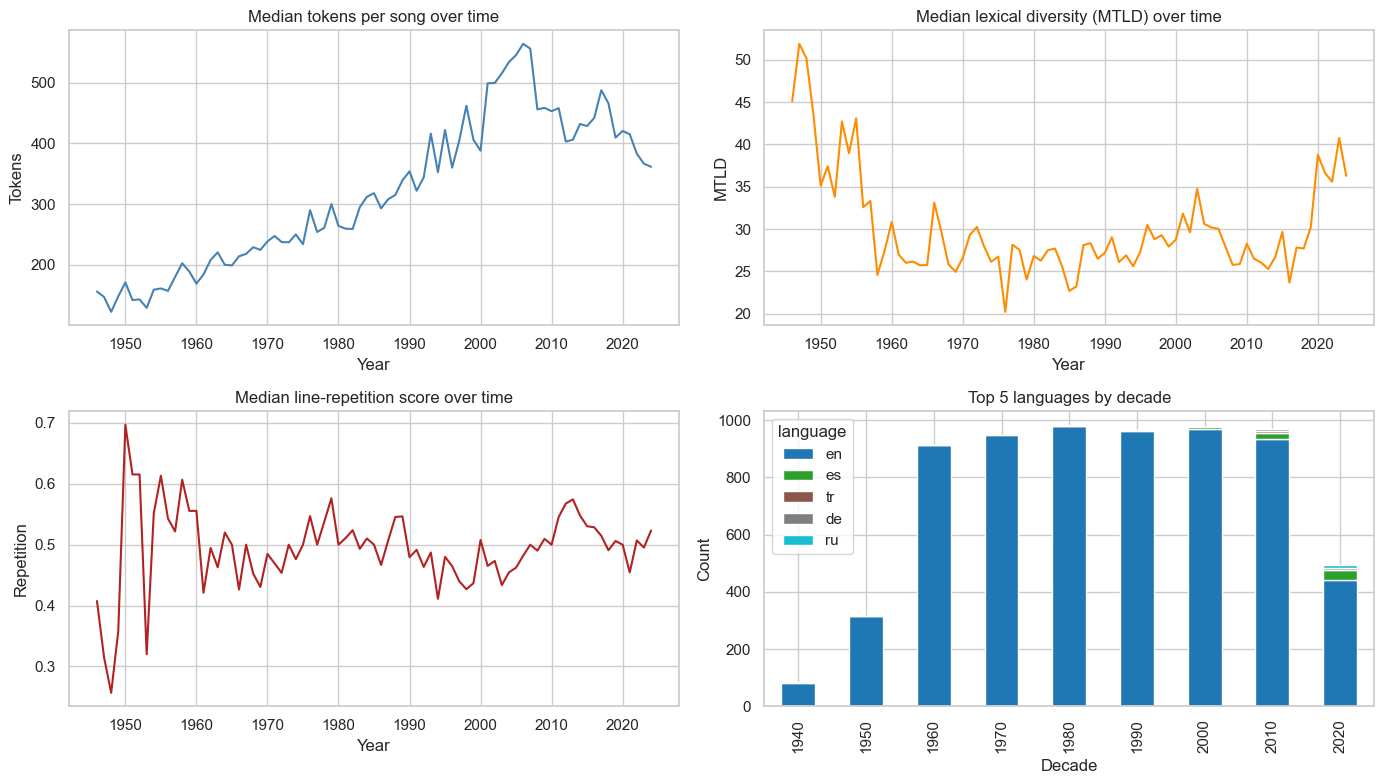

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Length over time
df.groupby("year")["n_tokens"].median().plot(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Median tokens per song over time")
axes[0, 0].set_xlabel("Year"); axes[0, 0].set_ylabel("Tokens")

# Lexical diversity (MTLD) over time
df.groupby("year")["mtld"].median().plot(ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Median lexical diversity (MTLD) over time")
axes[0, 1].set_xlabel("Year"); axes[0, 1].set_ylabel("MTLD")

# Repetition over time
df.groupby("year")["repetition_score"].median().plot(ax=axes[1, 0], color="firebrick")
axes[1, 0].set_title("Median line-repetition score over time")
axes[1, 0].set_xlabel("Year"); axes[1, 0].set_ylabel("Repetition")

# Language breakdown over decade
lang_decade = (df.groupby(["decade", "language"]).size()
                 .unstack(fill_value=0))
top_langs = lang_decade.sum().nlargest(5).index
lang_decade[top_langs].plot(ax=axes[1, 1], kind="bar", stacked=True, colormap="tab10")
axes[1, 1].set_title("Top 5 languages by decade")
axes[1, 1].set_xlabel("Decade"); axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Save preprocessed data

The output parquet contains every song with all three text views and per-song stats. Subsequent notebooks load from this file.

In [7]:
output = PROCESSED_DIR / "songs_preprocessed.parquet"
df.to_parquet(output)
print(f"Saved {len(df):,} preprocessed songs to {output.name}")
print(f"\nColumns: {list(df.columns)}")
print(f"Total disk size: {output.stat().st_size / 1e6:.1f} MB")

Saved 6,707 preprocessed songs to songs_preprocessed.parquet

Columns: ['id', 'year', 'decade', 'rank', 'title', 'artist', 'title_norm', 'artist_norm', 'source', 'url', 'lyrics_text', 'word_count', 'language', 'tokens', 'lemmas', 'n_tokens', 'n_types', 'ttr', 'mtld', 'n_lines', 'repetition_score']
Total disk size: 13.1 MB


## Cleanup: drop degenerate rows

A few songs got through the `n_tokens >= 30` filter in notebook 1 because their `word_count` (from the database, based on whitespace splitting) was above 30 but their tokenized count is much lower. These are usually lyrics in non-Latin scripts (Korean, Japanese) where our regex-based tokenizer drops everything.

In [8]:
# Drop rows where tokenization yielded very few tokens
# (usually non-Latin script that our regex tokenizer can't handle)
before = len(df)
df = df[df["n_tokens"] >= 30].copy().reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with <30 tokens after proper tokenization")
print(f"Final corpus: {len(df):,} songs")

# Re-save the cleaned parquet
df.to_parquet(PROCESSED_DIR / "songs_preprocessed.parquet")
print("Re-saved songs_preprocessed.parquet")

Dropped 11 rows with <30 tokens after proper tokenization
Final corpus: 6,696 songs
Re-saved songs_preprocessed.parquet
